In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from ISLP import load_data

from sklearn.cluster import (KMeans, AgglomerativeClustering )
from scipy.cluster.hierarchy import (dendrogram, cut_tree)
from ISLP.cluster import compute_linkage

## (a) Generating simulated dataset

In [9]:
np.random.seed(42)

n_per_class = 20
n_classes = 3
n_variables = 50
total_obs = n_per_class * n_classes

# create noise from normal function
X = np.random.normal(loc=0, size=(total_obs, n_variables))

# Apply mean shifts to make classes distinct
X[0:20] += -2
X[20:40] += 0
X[40:60] += 2

# # Generate labels (y)
y = np.repeat([0, 1, 2], n_per_class)

# Convert to DataFrame for easier handling
df = pd.DataFrame(X, columns=[f'var_{i}' for i in range(n_variables)])
df['label'] = y

feats = df.drop(columns=['label'])

## (b) Perform PCA on dataset

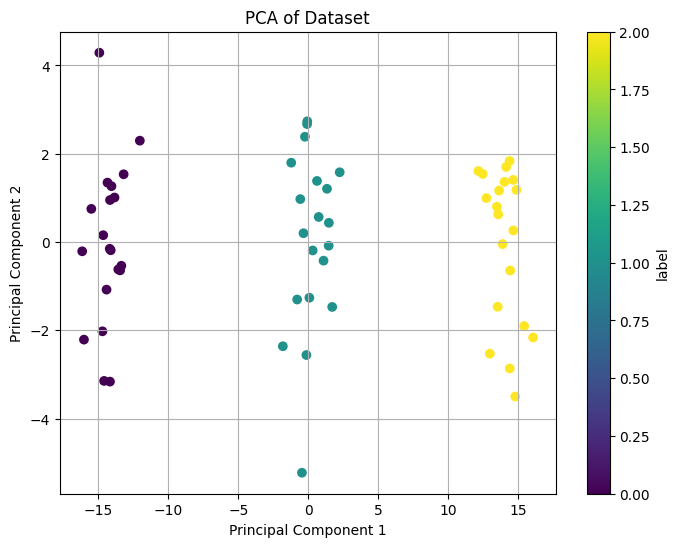

In [10]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(feats)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

plt.figure(figsize=(8, 6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df['label'])
plt.title('PCA of Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='label')
plt.grid()
plt.show()

## (c) K-means with k=3

KMeans        0   1   2
True Labels            
0             0   0  20
1            20   0   0
2             0  20   0


Text(0.5, 1.0, 'K-Means Clustering Results with K=3')

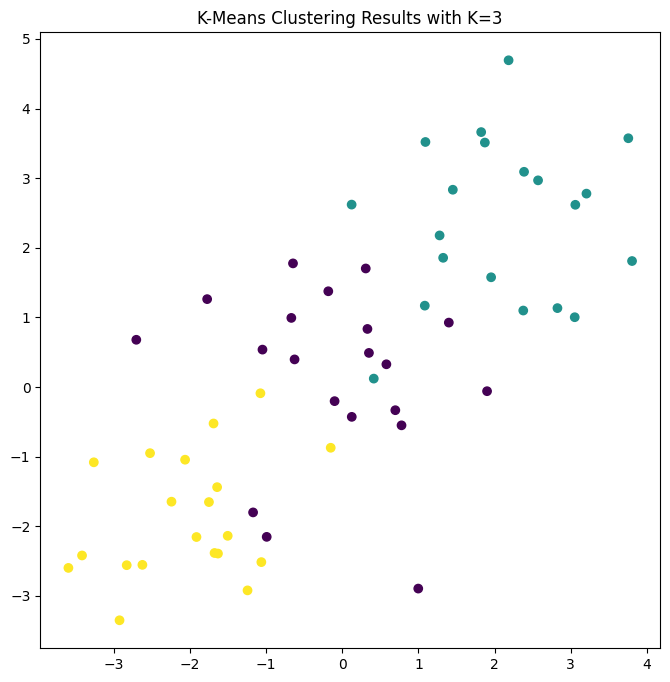

In [11]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(feats)

print(pd.crosstab(pd.Series(df['label'], name='True Labels'), pd.Series(kmeans.labels_, name='KMeans')))

fig , ax = plt.subplots(figsize =(8 ,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=3")

As shown, when `pd.crosstab()` was used, the result of the KMeans appeared to have clustered all of the data with no points being in the wrong cluster. On the other hand, when plotting the results, we can see an overlap of some points that were clustered being in closer proximity to another cluster.

## (d) K-means with k=2

KMeans        0   1
True Labels        
0            20   0
1            20   0
2             0  20


Text(0.5, 1.0, 'K-Means Clustering Results with K=2')

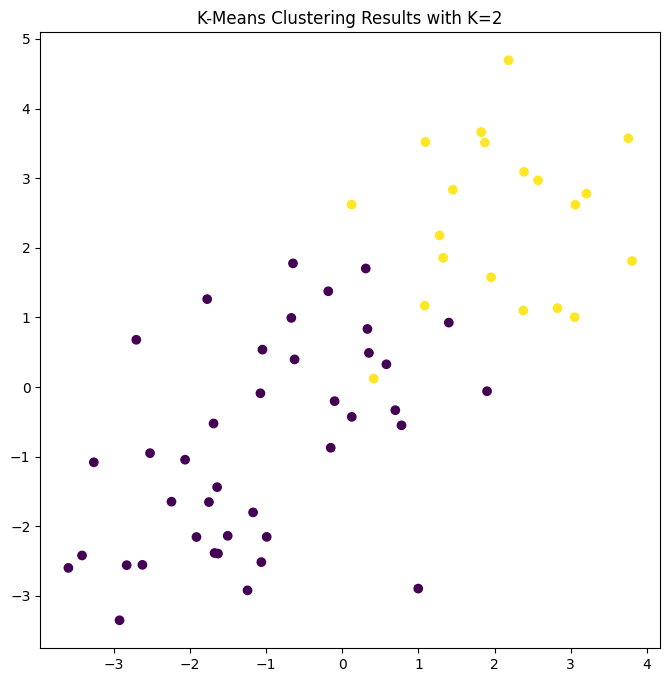

In [12]:
kmeans = KMeans(n_clusters=2, random_state=42).fit(feats)

print(pd.crosstab(pd.Series(df['label'], name='True Labels'), pd.Series(kmeans.labels_, name='KMeans')))

fig , ax = plt.subplots(figsize =(8 ,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=2")

By using K=2, we can see that Kmeans was unable to distinguish between the three distinct classes. It resulted in two of the classes being classified as one which ends up in a misclassification for an entire class.

## (e) K-means with k=4

KMeans       0   1   2   3
True Labels               
0            0   0  20   0
1            8   0   0  12
2            0  20   0   0


Text(0.5, 1.0, 'K-Means Clustering Results with K=4')

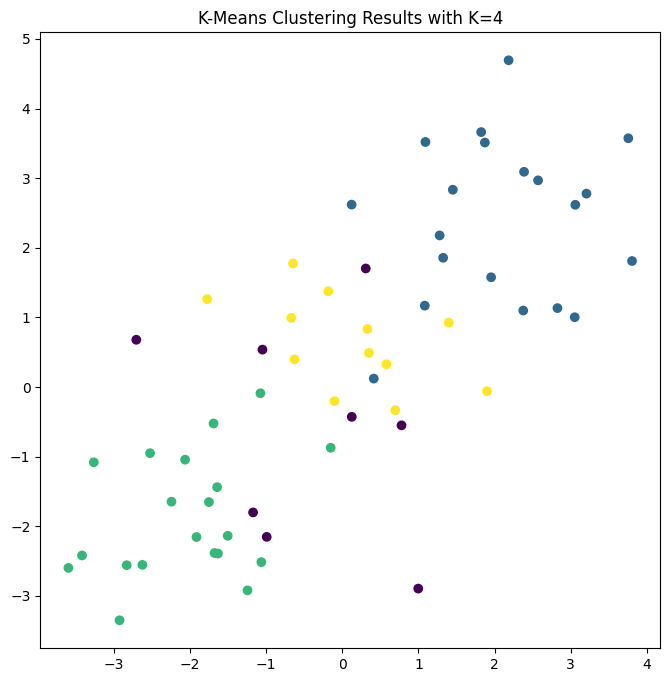

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42).fit(feats)

print(pd.crosstab(pd.Series(df['label'], name='True Labels'), pd.Series(kmeans.labels_, name='KMeans')))

fig , ax = plt.subplots(figsize =(8 ,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=4")

As shown in the plot, using k=4 for Kmeans results in four distinct clusters to be classified. By adding one more class than the true three classes, Kmeans ended up creating an unnecessary cluster that classified points that belonged to the other existing classes.

## (f) Kmeans on the PCA df

KMeans        0   1   2
True Labels            
0             0  20   0
1            20   0   0
2             0   0  20


Text(0.5, 1.0, 'K-Means Clustering Results with K=3')

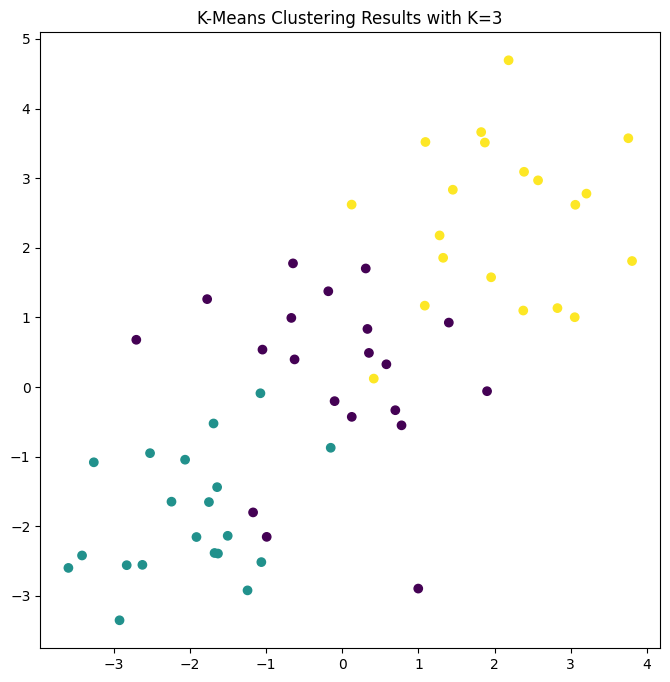

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42).fit(pca_df)

print(pd.crosstab(pd.Series(df['label'], name='True Labels'), pd.Series(kmeans.labels_, name='KMeans')))

fig , ax = plt.subplots(figsize =(8 ,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=3")

Performing Kmeans on the PCA dataframe with k=3 yielded the same results as doing Kmeans using k=3 on the base dataset. This may be because the shape or transforms of the data did not chnage by using this method.

## (g) Kmeans with StandardScaler

KMeans Scaled   0   1   2
True Labels              
0               0   0  20
1              20   0   0
2               0  20   0


Text(0.5, 1.0, 'K-Means Clustering Results with K=3')

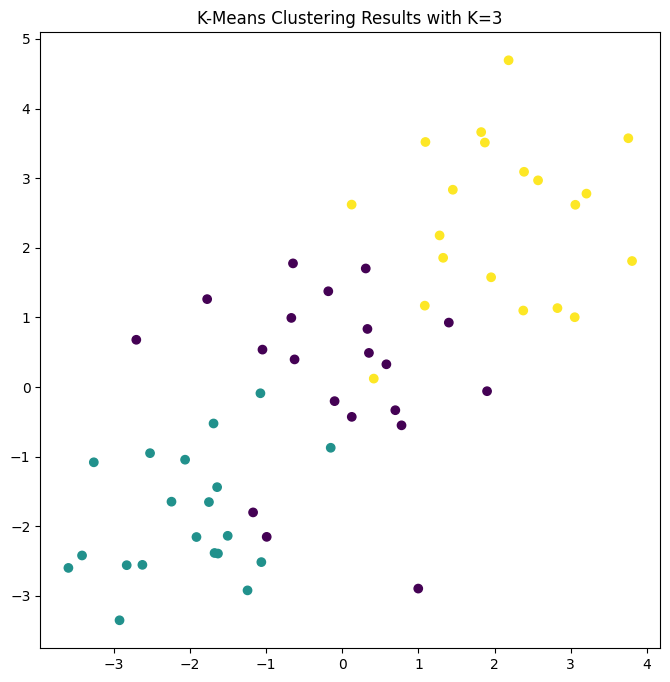

In [16]:
scaler = StandardScaler()

scaled_feats = scaler.fit_transform(feats)

kmeans_scaled = KMeans(n_clusters=3, random_state=42).fit(scaled_feats)

print(pd.crosstab(pd.Series(df['label'], name='True Labels'), pd.Series(kmeans_scaled.labels_, name='KMeans Scaled')))

fig , ax = plt.subplots(figsize =(8 ,8))
ax.scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax.set_title("K-Means Clustering Results with K=3")

By scaling the data, the data seem to be more cohesive in terms of them being closer together, but the performance of Kmeans with k=3 pales in comparison to the PCA results in part (b). PCA is the clear best performer in this case because Kmeans produces clusters that contain points that should have been classified with another cluster while PCA has three distinct clusters with no overlap.